> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.

# **IS 4487 LAB 4: DATA UNDERSTANDING**

## Outline

- Load and preview a real-world dataset
- Inspect structure and profile the data: data types, distributions, identify missing or unusual data such as outliers
- Perform basic grouped summaries

We are focused on the Data Understanding phase in business analytics. The tasks in this lab will help you figure out what the data actually contains before you start making decisions or building models. By exploring the dataset, you can identify key details such as the meaning of each column, the data types (numeric, categorical, etc.), the presence of missing or inconsistent values, and the overall size and structure of the data. It’s also important to look for patterns, unusual values, or outliers that could affect your analysis. Taking the time to understand your data early helps prevent mistakes, ensures your analysis is accurate, and guides you toward asking the right questions.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Labs/lab_04_data_understanding.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

If you have any questions about Colab, you can read more here:
https://research.google.com/colaboratory/faq.html

## **Business Context: Rental Housing Market in the Bay Area**

## Dataset Overview

This week we will use data on Bay Area Craigslist rental housing posts.

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by real estate companies, rental platforms, investors, or property managers to better understand pricing trends and market dynamics. The variables provide multiple angles for analysis: pricing (`price`) can be compared with property features like size (`sqft`), `bedrooms` and `bathrooms`, and whether the listing is a full apartment or just a room; location data (`nhood`, `lat`, `lon`) allows for geographic analysis of rent differences across neighborhoods; and time variables (`date`, `year`) help track how the market changes over time. Text fields like `title` and `descr` can even be analyzed to understand how listings are marketed. By exploring this dataset, analysts can answer questions such as what factors drive higher rent, which `neighborhoods` are most expensive, or how `prices` have changed over time. This kind of analysis is valuable for setting competitive prices, identifying investment opportunities, and helping renters or companies make informed housing decisions.

Note that many of the columns (variables) will be empty. This is an unfortunate reality in the real world!

Some rentals are apartments, others are for homes, and there may be some other random properties for rent. Each row represents one rental listing.


**Source:** Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018.

`rent.csv` Retrieved from [TidyTuesday – 2022-07-05](https://github.com/rfordatascience/tidytuesday/blob/main/data/2022/2022-07-05/rent.csv)


| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     |  Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1). |
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |

## **Part 1: Importing the Libraries and Data**

### Instructions:
- Import the `pandas` library for dataframes. Then `matplotlib` and `seaborn` for data visualization.
- Import data from the `rent.csv` into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

### Note on importing data:
- In this lab we will be importing data from a web URL, rather than a Python library.
  - GitHub can host text files as well as code. In this case we are pulling the data directly from the TidyTuesday GitHub account into a dataframe in this file.
- A "`CSV`" file is a text file that has comma separated values. You can open the file in Excel, Pandas, or in a notepad on your laptop.

In [1]:
# import any libraries that you wish to use
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

We can use a function in pandas called `read_csv()` to read in `csv` files. It is called using `pd.read_csv('url')` where 'url' provides the location of the file on the Internet.

Similarly there are other functions such as  `read_excel()`, `read_json()`, `read_html()` etc.

In [2]:
# import data

url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-07-05/rent.csv'
df = pd.read_csv(url)

In [3]:
# view some metadata about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200796 entries, 0 to 200795
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200796 non-null  object 
 1   date         200796 non-null  int64  
 2   year         200796 non-null  int64  
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  int64  
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  int64  
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8016 non-null    object 
dtypes: float64(5), int64(4), object(8)
memory usage: 26.0+ MB


In [4]:
# view the first 5 rows of the table
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005,alameda,alameda,alameda,1250,2.0,2.0,NaN,0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005,alameda,alameda,alameda,1295,2.0,NaN,NaN,0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004,alameda,alameda,alameda,1100,2.0,NaN,NaN,0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012,alameda,alameda,alameda,1425,1.0,NaN,735.0,0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004,alameda,alameda,alameda,890,1.0,NaN,NaN,0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


### **🔧 Try It Yourself - Part 1**

🔧 1.1. Add one line of code to print the number of rows and columns.

In [5]:
# 🔧 1.1. Add code here


## **Part 2: Inspect/Profile Data**

### Instructions:
- Check ***data types*** (e.g., dates, numeric columns). These are inferred. Do they look appropriate?
- Identify whether variables have ***missing values***.
- Check for ***duplicates***
- Check for ***outliers*** in key numeric variables like `price`, `sqft`, `beds`, or `baths`. Outliers are extreme or unusally low or high values compared to most others.
  - Outliers will be covered more in week 6. This week we will do only a very basic filter for outlier values.

### Data types

The Dataframe attribute `.dtypes` tells us the data type of each variable in the table.

NOTICE: there are no parentheses at the end of `.dtypes`

In [6]:
# Check data types
df.dtypes

,0
post_id,object
date,int64
year,int64
nhood,object
city,object
county,object
price,int64
beds,float64
baths,float64
sqft,float64


Data types are inferred.
- Numeric values: are either *int* (discrete, whole numbers with no limit) or *float* (continuous decimals with no limit). 64 is the default number of bits used to store the *int* or *float*.
- String/text: is stored as *object*.
- Note that the inferred datatypes are not always ideal. In the future, we will learn how to change data types. For instance, *category* and *datetime* types are not detected automatically. We have to set that.

### Missing Values
check `df.info()` above - that tells us how many missing values each column has.

Here is another command to do the same using `.isnull()`, which produces a 0 or 1 for each cell in the table

`.sum()` provides the answer as a sum of missing values for each column

In [7]:
# Check for missing values - get a count for each column
df.isnull().sum()

,0
post_id,0
date,0
year,0
nhood,0
city,0
county,1394
price,0
beds,6608
baths,158121
sqft,136117


NOTE: Most predictive ML models will drop rows that have ANY missing values. Some columns have many missing values. We will see in a future lab how to optimally deal with missing values, which will depend on its data type.

### Duplicates

Check whether there are rows that are exact duplicates of another. These cause issues because they will be given more weight than other regular rows.

In [8]:
# Check for exact duplicates
df.duplicated().sum()


np.int64(0)

### Outlier analysis
Outliers are data points that are very different in value from the rest.
Take a look at `descriptive or summary statistics` for a few columns.

Do you see any potential outliers?

In [9]:
# Basic summary statistics for a few columns
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,200796.000000,194188.000000,42675.000000,64679.000000
mean,2135.362746,1.889025,1.679086,1201.827688
std,1427.747903,1.079138,0.690509,5000.217864
min,220.000000,0.000000,1.000000,80.000000
25%,1295.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2505.000000,3.000000,2.000000,1360.000000
max,40000.000000,12.000000,8.000000,900000.000000


We can also create a ***boxplot*** of one variable to visually understand outliers in that column.

In a boxplot,
- the box covers the interquartile range (IQR) from 25-75 percentile of the data, and
- the whiskers (T lines) extend to a certain range (1.5 times the IQR) from the box.
- Any data points that fall outside of this whisker range are considered outliers and are plotted individually as points.

Let us create a boxplot for `price` - a potential target variable of interest.

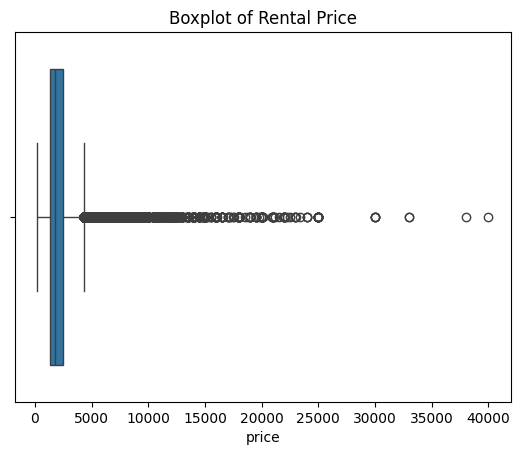

In [10]:
# Boxplot of price
sns.boxplot(x=df['price'])
plt.title("Boxplot of Rental Price")
plt.show()

### **🔧 Try It Yourself – Part 2**

2.1. Use `.describe()` to inspect the square footage `sqft` by itself.

2.2 Use a boxplot to see the outliers in `sqft`.

2.3. What patterns or issues do you see with square footage values? Is there anything unusual?

In [11]:
# 🔧 2.1. Add code here



In [12]:
# 🔧 2.2. Add code here



### ✍️ Your Response: 🔧

2.3. Add comment here:

## **Part 3: Grouped Data Exploration**

### Instructions:

- Use `.groupby()` and `.value_counts()` to summarize trends across `neighborhoods` and `cities`.
- `.groupby()` is used to group the data on some key column
- `.value_counts()` provides a count of values in each grouping

In [13]:
# Average price by neighborhood, sorted in desc order
df.groupby('nhood', observed = True)['price'].mean().sort_values(ascending=False).head(10)

,price
nhood,
inverness,5310.000000
atherton,4536.010989
tiburon / belvedere,4265.346591
financial district,3958.161417
west portal / forest hills,3827.276119
saratoga,3801.850900
kentfield / ross,3611.577855
los altos,3605.047072
SOMA / south beach,3585.900793


In [14]:
# Top cities by count - show top 10
df['city'].value_counts().head(10)

,count
city,
san francisco,55730
san jose,13733
oakland,9443
santa rosa,6230
santa cruz,5464
san mateo,5127
sunnyvale,4526
mountain view,4414
berkeley,4201


### **🔧 Try It Yourself – Part 3**

Explore the data by performing the following:

3.1. Group the listings by `year` and calculate the average price for each `year`. Sort the results by `year`.

3.2. Create a line chart to show the average price by `year` (from step 1)

3.3. Use `.value_counts()` on the `room_in_apt` column to see how common room rentals are.

In [19]:
# 🔧 3.1. Add code here
avg_price_by_year = df.groupby('year')['price'].mean().sort_index()
avg_price_by_year

,price
year,
2000,1418.695652
2001,2070.038095
2002,1709.347079
2003,1587.705745
2004,1640.209812
2005,1525.475233
2006,1822.992589
2007,2152.303178
2008,2067.772489


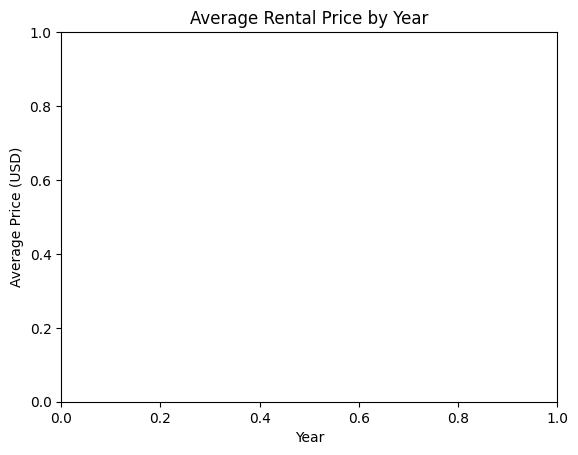

In [20]:
# 🔧 3.2 Add code here avg_price_by_year.plot(kind='line', marker='o')
plt.title("Average Rental Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price (USD)")
plt.show()


In [21]:
# 🔧 3.3 Add code here df['room_in_apt'].value_counts()


## **Part 4: Reflection 🔧**
Please answer the following in your own words.

4.1. Explain, in detail, any trends you see with `year` and `room_in_apt`.

4.2. What would be the right way to handle missing data in several of the variables? Are those variables usable and useful? Can any be dropped/removed?


✍️ Your Response: 🔧

4.1.Average rental price roughly doubled over the period. In the early 2000s the average was around 1,400 to 1,700 dollars, and by 2015 to 2018 it was around 3,000 dollars. Prices dipped around 2009 and 2010, which lines up with the recession, and then climbed sharply starting in 2013, which matches the Bay Area tech boom. One caution is that the number of listings per year is very uneven. For example, 2000 has only 23 listings while 2004 has over 41,000 and 2012 has over 35,000. Years with very few listings (2000 to 2002, 2017 to 2018) give less reliable averages, so the line chart should be read with that in mind. For room_in_apt, room rentals are very rare: only 285 of the roughly 200,800 listings (about 0.14%) are single rooms, and the rest are entire units. Room rentals show up slightly more often in some later years such as 2014 and 2017, but the counts are too small to call it a real trend.

4.2.The right approach depends on how much of each column is missing. Columns that are almost entirely empty, such as address, lat, lon, descr, and details (each over 96% missing), can be dropped because filling them in would mostly be guessing. Columns with only a small amount missing, like beds (about 3%) and county (under 1%), are still usable. We could drop those few rows or fill beds with the median. The harder cases are baths (about 79% missing) and sqft (about 68% missing). Both are useful for explaining price, but dropping every row with a missing value would throw away most of the data. Options are to analyze only the rows that have these values, to fill them using related information (for example, the typical sqft for a given number of beds), or to leave them out of a model. Sqft also needs its extreme outliers cleaned before it can be used.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [18]:
!jupyter nbconvert --to html "lab_04_LastnameFirstname.ipynb"

[NbConvertApp] WARNING | pattern 'lab_04_LastnameFirstname.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]


## Submit your assignment

- Make sure that all of your output is shown.
When there are multiple subtasks, good ideas to write code for each in its own cell.
- If you use AI, it is your responsibility to clean up the AI code. Only keep the outputs relevant to each subtask or task question.
- Upload your `HTML file` to Canvas. make sure that your lastnamefirstname are part of the filename as requested above
- Optionally, save your file in your own GitHub account for future use